# 03 — Generadores M2 (Timoshenko) y M3 (conicidad)

Tarea **T37**. M1 (soporte flexible) es el eje principal del estudio, con 6 severidades. M2 y M3 son **otro tipo de error** con **una sola severidad cada uno**. Sirven para responder: *¿el orden de los métodos se mantiene cuando cambia la causa del error?*

| | Qué falta en el modelo simple | Efecto típico |
|---|---|---|
| **M2** | Deformación por cortante e inercia rotatoria (Timoshenko) | Baja las frecuencias, mucho más en modos altos. Importa en vigas cortas y gruesas |
| **M3** | Espesor no uniforme: h(ξ) = h̄·(1 + α·(ξ − ½)) | Cambia rigidez y masa a lo largo de la viga |

**Cómo se eligió la severidad única:** se iguala a M1 s3, el nivel de 5%.

- **M2:** en la viga del NIST (L/h ≈ 110) el cortante es despreciable (0.01% en E), así que se acorta la viga, con el mismo ancho y espesor, hasta que el sesgo en E llega a 5%.
- **M3, voladizo:** el α que da 5% de sesgo en E.
- **M3, biempotrada:** la frecuencia casi no reacciona a la conicidad, así que se iguala la **diferencia de forma** de M1 s3 (2.2%).

**Nota sobre M3:** el plan escribe h(ξ) = h₀·(1 + α·ξ). Es la misma familia, pero aquí se centra en el espesor medio h̄. Con la forma del plan, la mayor parte del efecto sería un espesor medio equivocado y no la falta de uniformidad.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pinn_mems import Soporte, Viga, cargar_config, generar, resolver_modos
from pinn_mems.eigensolver import Timoshenko
from pinn_mems.severidad import severidad

COLORES = ["#2a78d6", "#eb6834", "#1baf7a"]
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.6,
    "lines.linewidth": 2, "figure.dpi": 110,
})
viga = Viga(E=70e9, L=300e-6, b=28e-6, h=2.743e-6, rho=2200.0)  # RM 8096
ESTRUCTURAS = ["voladizo", "biempotrada"]
tabla = pd.read_csv("../datos/sinteticos/calibracion.csv")

## 1. Las tres "severidades de 5%" lado a lado

Las tres tienen un tamaño comparable, pero cada una deja una huella distinta: **M1** mueve todo un poco, **M2** golpea los modos altos y **M3** en la biempotrada cambia la forma sin tocar la frecuencia.

In [2]:
comparar = tabla[tabla.nombre.str.match(r"m1_.*_s3|m2_|m3_")].copy()
vista = pd.DataFrame({
    "config": comparar.nombre,
    "parámetro": [
        f"κ_θ = {r.kappa_theta:.1f}" if r.generador == "M1"
        else f"L = {1e6 * float(r.L):.1f} µm (L/h = {float(r.L) / viga.h:.1f})" if r.generador == "M2"
        else f"α = {float(r.alpha):.4f}"
        for r in comparar.itertuples()
    ],
    "sesgo E (%)": (100 * comparar.sesgo_E).round(2),
    "Δω₁ (%)": (100 * comparar.corrimiento_omega1).round(2),
    "Δω₃ (%)": (100 * comparar.corrimiento_omega3).round(2),
    "dif. forma (%)": (100 * comparar.diferencia_forma).round(2),
})
vista.set_index("config")

,parámetro,sesgo E (%),Δω₁ (%),Δω₃ (%),dif. forma (%)
config,,,,,
m1_voladizo_s3,κ_θ = 76.1,-5.00,-2.53,-2.34,2.96
m2_voladizo,L = 14.4 µm (L/h = 5.2),-5.00,-2.53,-26.05,12.51
m3_voladizo,α = 0.0415,-5.00,-2.53,-0.28,1.47
m1_biempotrada_s3,κ_θ = 150.3,-5.00,-2.53,-2.43,2.21
m2_biempotrada,L = 42.1 µm (L/h = 15.4),-5.00,-2.53,-9.24,2.56
m3_biempotrada,α = 0.0491,-0.03,-0.01,-0.01,2.21


## 2. M2: cuándo importa el cortante

Sesgo en la frecuencia de cada modo contra la esbeltez L/h, con el mismo ancho y espesor. La línea vertical gris marca la viga del NIST: ahí el efecto no se ve. El punto es la severidad calibrada.

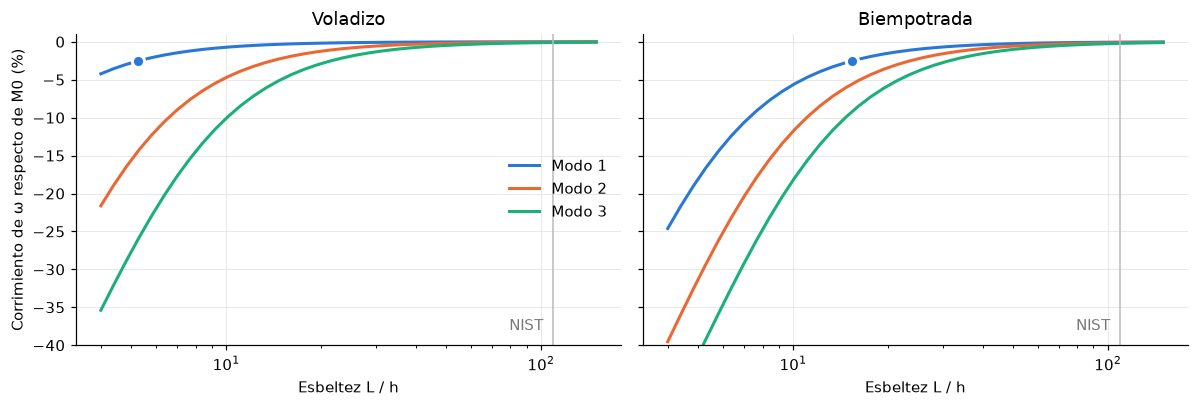

In [3]:
esbelteces = np.geomspace(4, 150, 40)
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for eje, est in zip(ejes, ESTRUCTURAS):
    corr = []
    for e in esbelteces:
        v = Viga(**{**viga.__dict__, "L": e * viga.h})
        corr.append(resolver_modos(v, est, timoshenko=Timoshenko()).omega / resolver_modos(v, est).omega - 1)
    corr = 100 * np.array(corr)
    for m in range(3):
        eje.semilogx(esbelteces, corr[:, m], color=COLORES[m], label=f"Modo {m + 1}")
    cal = tabla.query(f"nombre == 'm2_{est}'").iloc[0]
    eje.plot(float(cal.L) / viga.h, 100 * cal.corrimiento_omega1, "o", color=COLORES[0],
             markersize=8, markeredgecolor="white", markeredgewidth=2)
    eje.axvline(viga.L / viga.h, color="#bbb", linewidth=1)
    eje.text(viga.L / viga.h * 0.93, -38, "NIST", color="#777", ha="right")
    eje.set_title(est.capitalize())
    eje.set_xlabel("Esbeltez L / h")
ejes[0].set_ylabel("Corrimiento de ω respecto de M0 (%)")
ejes[0].set_ylim(-40, 1)
ejes[0].legend(frameon=False, loc="center right")
fig.tight_layout()

**Ojo con el voladizo de M2:** para llegar al 5% en E hace falta L/h ≈ 5 (L ≈ 14 µm). Es una viga muy corta, al límite de la teoría de vigas, y su modo 3 baja 26%. Es un caso de estrés más que un dispositivo típico. La biempotrada llega al 5% con L/h ≈ 15, mucho más plausible.

## 3. La huella de cada mecanismo en la forma modal

Las formas de M1, M2 y M3 se ven casi iguales a las de M0, así que se grafica la **diferencia** w_generador − w_M0. Esta huella es lo que un método de discrepancia (L2) o uno con física extra (L3) tendría que capturar.

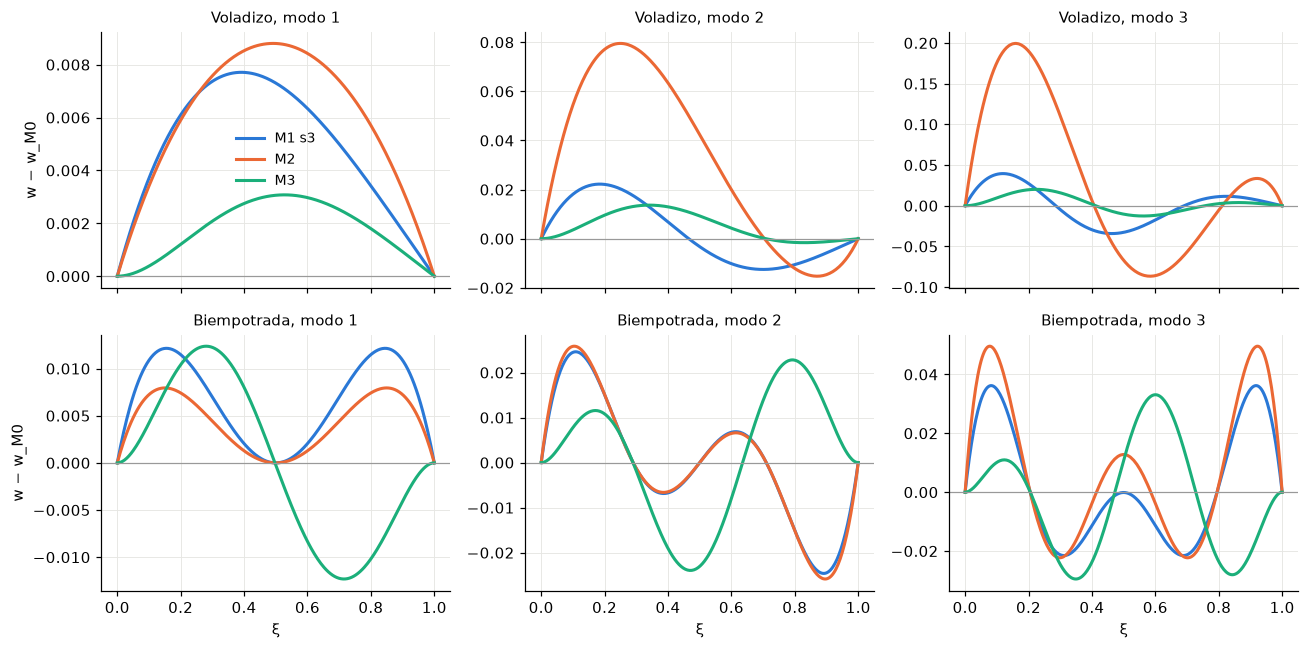

In [4]:
xi = np.linspace(0, 1, 300)
fig, ejes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for fila_ejes, est in zip(ejes, ESTRUCTURAS):
    m0 = resolver_modos(viga, est).forma(xi)
    k3 = float(tabla.query(f"nombre == 'm1_{est}_s3'").kappa_theta.iloc[0])
    L2 = float(tabla.query(f"nombre == 'm2_{est}'").L.iloc[0])
    a3 = float(tabla.query(f"nombre == 'm3_{est}'").alpha.iloc[0])
    corta = Viga(**{**viga.__dict__, "L": L2})
    huellas = {
        "M1 s3": resolver_modos(viga, est, Soporte(kappa_theta=k3)).forma(xi) - m0,
        "M2": resolver_modos(corta, est, timoshenko=Timoshenko()).forma(xi) - resolver_modos(corta, est).forma(xi),
        "M3": resolver_modos(viga, est, alpha=a3).forma(xi) - m0,
    }
    for m, eje in enumerate(fila_ejes):
        for c, (nombre, d) in enumerate(huellas.items()):
            eje.plot(xi, d[m], color=COLORES[c], label=nombre)
        eje.axhline(0, color="#999", linewidth=0.8)
        eje.set_title(f"{est.capitalize()}, modo {m + 1}", fontsize=10)
    fila_ejes[0].set_ylabel("w − w_M0")
for eje in ejes[-1]:
    eje.set_xlabel("ξ")
ejes[0, 0].legend(frameon=False, fontsize=9)
fig.tight_layout()

Lo que se ve:

- **M1** concentra el cambio cerca del soporte, porque w′(0) ≠ 0, y crece hacia la punta.
- **M2** casi no toca el modo 1, pero deforma mucho los modos 2 y 3.
- **M3** en la biempotrada es **antisimétrico**: la viga deja de ser simétrica. Un método que solo mida frecuencias no lo ve; uno que mida formas, sí.
- **En la biempotrada, M2 y M1 dejan huellas muy parecidas**, ambas simétricas y con el mismo patrón. Un método L3 que agrega resortes de soporte podría "explicar" el cortante como un anclaje flexible y dar un E equivocado con mucha confianza. Es justo lo que M2 debe poner a prueba.

## 4. Generar los conjuntos

Las configs están en `datos/sinteticos/configs/m2_*.yaml` y `m3_*.yaml`, y se regeneran con `python scripts/generar_sinteticos.py`.

In [5]:
from pathlib import Path

for ruta in sorted(Path("../datos/sinteticos/configs").glob("m[23]_*.yaml")):
    c = generar(cargar_config(ruta))
    f = ", ".join(f"{x / 1e3:.1f}" for x in c.omega / (2 * np.pi))
    extra = {k: c.params[k] for k in ("L", "nu", "kappa_s", "alpha") if k in c.params}
    print(f"{c.nombre:16s} f = [{f}] kHz   {extra}")

m2_biempotrada   f = [8725.5, 23297.5, 43907.2] kHz   {'L': 4.215e-05, 'nu': 0.17, 'kappa_s': 0.8435472242249458}
m2_voladizo      f = [11750.1, 64652.9, 156429.5] kHz   {'L': 1.4399e-05, 'nu': 0.17, 'kappa_s': 0.8435472242249458}
m3_biempotrada   f = [176.7, 487.1, 954.8] kHz   {'L': 0.0003, 'alpha': 0.049086}
m3_voladizo      f = [27.1, 172.7, 486.0] kHz   {'L': 0.0003, 'alpha': 0.041516}


## Pendientes

- Con la PINN y la inversa clásica listas, correr la escalera L0–L3 sobre M2 y M3 y comparar el orden de los métodos con el de M1 s3 (T37).
- Si el asesor prefiere una geometría de M2 más realista, cambiar el criterio en `scripts/calibrar_severidad.py`, por ejemplo fijar L/h ≈ 15 en ambas estructuras y aceptar un sesgo menor en el voladizo.